# Notebook that generates the plots in the paper

Please ensure, that you have all models trained and evaluated first. We provided a simple bashscript running our models with a single Seed:
```bash
./run_all_models.sh
```
While training is fast, evaluating sequentially can take several days, as computing the EMD is computationally expensive.
The process can be fully parallelized on a cluster. Alternatively, it is possible to reduce the number of samples to speed up the evaluation process.



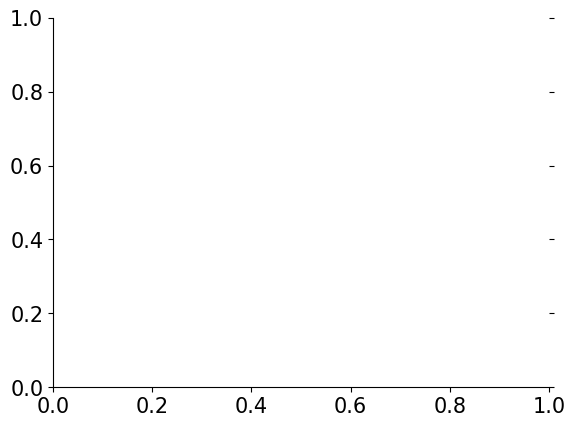

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
import os
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from utils.plotting_utils import clean_up, combine_multiple_datasets, read_and_combine_df

Base_path = "../plots/"
if not os.path.exists(Base_path):
    os.makedirs(Base_path)
SEEDS= [1] #,2,3,4,5]
NUM_EVAL_SAMPLES = 2000

In [3]:
models =[
        "SupeLORETA",
        "SupLassoPosZero"
]
models += [f"SupMNEVolLinear1024Seed{s}" for s in SEEDS]
models += [f"SupMNEVolConvDipSeed{s}" for s in SEEDS]
models += [f"SupMNEVolUnet32Seed{s}" for s in SEEDS]
        


# Signal to Noise Ratio


In [ ]:
#df = read_and_combine_df(models, mode="snr",dataset="MNEVolSUBJECTOAS004L512")
df = combine_multiple_datasets(models, mode="snr", datasets=[f"MNEVolSUBJECTOAS004L{NUM_EVAL_SAMPLES}"])
df_clean = clean_up(df, name_map_updated = {"SupLassoPosZero":"Lasso"})
df_small = df_clean[(~df_clean["Tuned"])&(df_clean["Std_Sources"]=="0.05-0.4")&(df_clean["N_Sources"]=="1-1")]# &(df_clean["ModelName"].str.startswith("MNEVol"))]
fig, ax = plt.subplots(1,3,figsize=(14,4))

for i, metric in enumerate(["Normalized EMD","Normalized MSE","Weighted Cosine"]):
    g = sb.lineplot(
        data=df_small,
        x="SNR", hue="Model", 
        y=metric,
        errorbar=("sd",4),
        palette="tab10",
        style="Model",
        ax=ax[i],
        markers=True,
        legend=i==2,
         linewidth=6,
        markersize=10,
        dashes=False,
    )
    if i ==0:
        ax[i].set_ylim(0, 1.3)
    if i ==2:
        ax[i].set_ylim(0, 1)
    if i ==1:
        ax[i].set_ylim(0, 3.5)


ax[2].legend(bbox_to_anchor=(0.45, 0.35), loc='lower left')#, borderaxespad=0)
plt.tight_layout()
plt.savefig(Base_path+"SNR-fullSNR_wConvNewerStd.pdf", dpi=800, bbox_inches='tight')

# Source Extent

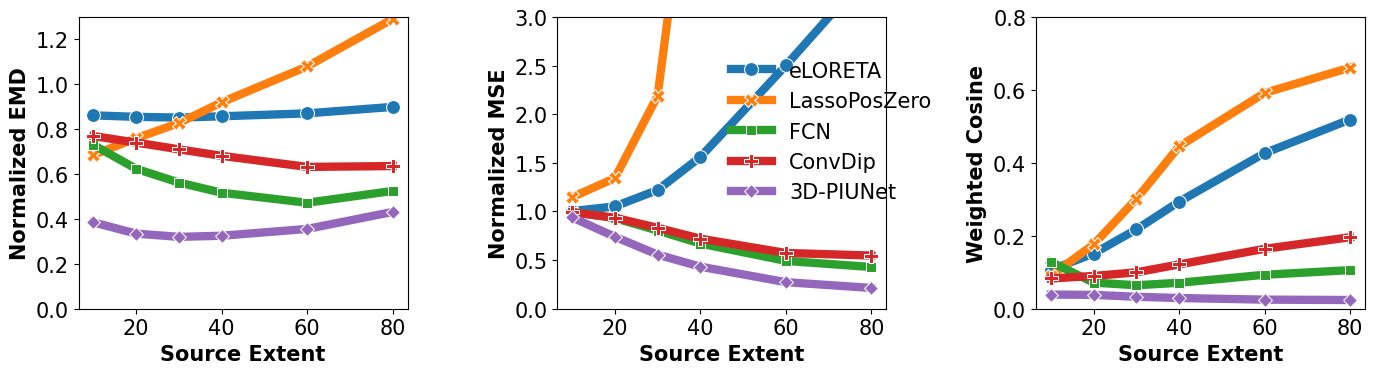

In [15]:
df = combine_multiple_datasets(models, mode="source_std", datasets=[f"MNEVolSUBJECTOAS004L{NUM_EVAL_SAMPLES}"])
df_clean = clean_up(df)
df_small = df_clean[(~df_clean["Tuned"])&(df_clean["SNR"]==5)]

fig, ax = plt.subplots(1,3,figsize=(14,4))
for i, metric in enumerate(["Normalized EMD","Normalized MSE","Weighted Cosine"]):
    g = sb.lineplot(
        data=df_small,
        x='Source Extent', hue="Model", 
        y=metric,
        errorbar=("sd",3),
        palette="tab10",
        style="Model",
        ax=ax[i],
        markers=True,
        legend=i==1,
         linewidth=6,
        markersize=10,
        dashes=False,
    )
    if i == 0:
        ax[i].set_ylim(0,1.3)
    if i ==1:
        ax[i].set_ylim(0, 3)
    if i ==2:
        ax[i].set_ylim(0,0.8)

ax[1].legend(bbox_to_anchor=(.47, 0.3), ncol=1, loc='lower left')
plt.tight_layout()
plt.savefig(Base_path+"SourceExtend-fullSNR5_wConvNewerStd.pdf", dpi=800, bbox_inches='tight')

# Number of Sources

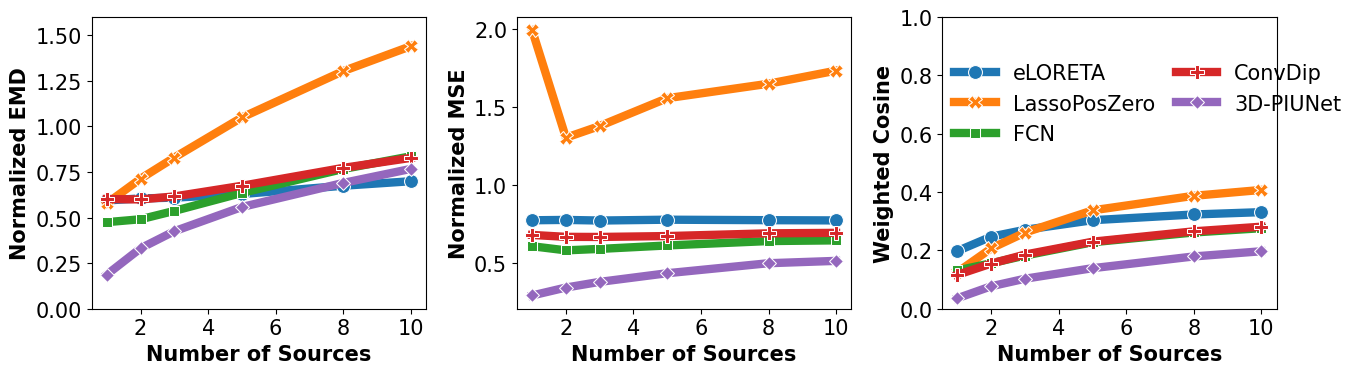

In [16]:
df = combine_multiple_datasets(models, mode="Nsources", datasets=[f"MNEVolSUBJECTOAS004L{NUM_EVAL_SAMPLES}"])
df_clean = clean_up(df)
df_small = df_clean[(~df_clean["Tuned"])&(df_clean["Std_Sources"]=="0.05-0.4")&(df_clean["SNR"]==20)]


fig, ax = plt.subplots(1,3,figsize=(14,4))
for i, metric in enumerate(["Normalized EMD","Normalized MSE","Weighted Cosine"]):
    g = sb.lineplot(
        data=df_small[df_small[metric].notna()],
        x='Number of Sources', hue="Model", 
        y=metric,
        errorbar=("sd",3),
        palette="tab10",
        style="Model",
        ax=ax[i],
        markers=True,
        legend=i==2,
         linewidth=6,
        markersize=10,
        dashes=False,
    )
    if i == 0:
        ax[i].set_ylim(0,1.6)
    if i ==4:
        ax[i].set_ylim(0, 1.4)
        ax_inset = fig.add_axes([ax[i].get_position().x0-0.009, 
                                 ax[i].get_position().y0 +0.5, 
                                 ax[i].get_position().width * 1.10, 
                                 ax[i].get_position().height * 0.4])

        sb.lineplot(
            data=df_small[df_small[metric].notna()],
            x='Number of Sources', 
            hue="Model", 
            y=metric,
            errorbar=("sd", 3),
            palette="tab10",
            style="Model",
            ax=ax_inset,
            markers=True,
            legend=False,  # Disable legend for the inset
            linewidth=6,
            markersize=10,
            dashes=False,
        )
    
        ax_inset.set_ylim(3, 5)  # Upper part of the y-axis range
        ax_inset.spines['bottom'].set_visible(False)
        ax_inset.set_xlabel('')
        ax_inset.set_ylabel('')
        ax_inset.set_xticks([])  # Remove x-ticks from inset
        ax[i].spines['top'].set_visible(False)
        d = .02  # Increase the size slightly for visibility
        kwargs = dict(transform=ax[i].transAxes, color='k', clip_on=False, linewidth=2)

        # Adjust the position of break markers in the inset
        kwargs.update(transform=ax_inset.transAxes)
        ax_inset.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal on the inset
        ax_inset.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-
        ax_inset.plot((-d, +d), (-2*d-d, -2*d+d), **kwargs)  # Top-left diagonal on the inset
        ax_inset.plot((1 - d, 1 + d), (-2*d-d, -2*d+d), **kwargs)  # Top-
        ax[i].set_yticks([0.0, 0.2, 0.4, 0.6])
        ax_inset.set_yticks([3.5,4.5])
    if i == 2:
        ax[i].set_ylim(0, 1)

ax[2].legend(bbox_to_anchor=(-0.02, 0.5), ncol=2, loc='lower left')
plt.tight_layout()
plt.savefig(Base_path+"NumberSources-fullSNR20_wConvNewerStd.pdf", dpi=800, bbox_inches='tight')

# Loss Overview

The corresponding models are not automatically trained via the run all models

evaluation is done on the small configuration with SNR in [0,5,20], Nsources in [1,10], and Source Extent in [0.05,0.4]
```bash
python evaluation_script.py --task_config small --cuda --batch_size 32 --max_length NUM_EVAL_SAMPLES --base_data MNEVolSUBJECTOAS004 --compute_emd  MODEL
```

In [5]:
# Reconstuction loss:
models_losses=(
    "SupMNEVolUnet32Lossl2",
    "SupMNEVolUnet32Seed1",
    "SupMNEVolUnet32LossRec0.000001",
    "SupMNEVolUnet32LossRec0.00001",
    "SupMNEVolUnet32LossRec0.0001",
)
name_update = {
    "SupMNEVolUnet32Seed1": "L1",
    "SupMNEVolUnet32LossRec0.0001": "Rec $\lambda=10^{-4}$",
    "SupMNEVolUnet32LossRec0.00001": "Rec $\lambda=10^{-5}$",
    "SupMNEVolUnet32LossRec0.000001": "Rec $\lambda=10^{-6}$",
    "SupMNEVolUnet32Lossl2": "L2",
}
df_losses = combine_multiple_datasets(models_losses, mode="small", datasets=[f"MNEVolSUBJECTOAS004Lf{NUM_EVAL_SAMPLES}"])


df_cleanlosses = clean_up(df_losses, name_map_updated=name_update)

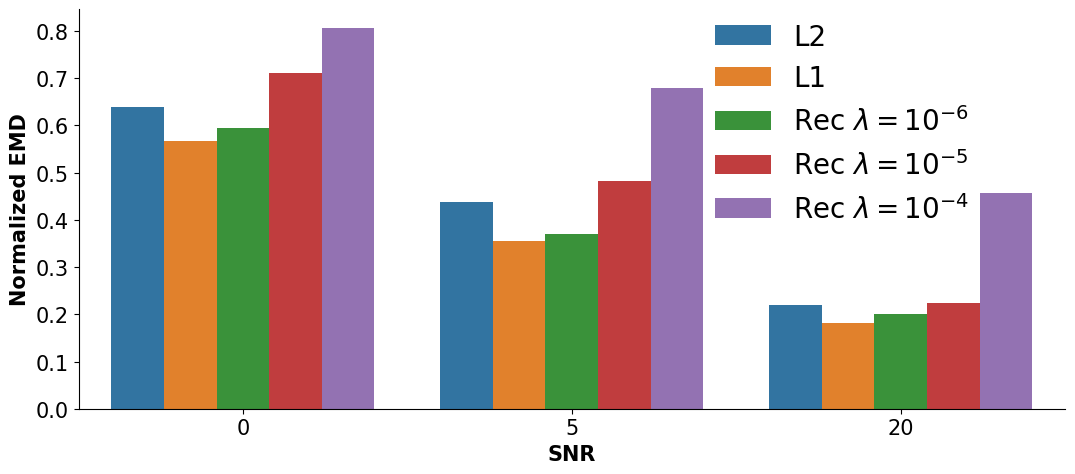

In [19]:
df_cleanlosses["Loss"] = df_cleanlosses["Model"]
df_cleanlosses = df_cleanlosses[df_cleanlosses["Number of Sources"]==1]
fig = sb.catplot(df_cleanlosses,hue="Loss", x="SNR",y="Normalized EMD",
           kind="bar", legend=False, aspect=2.2)
plt.legend(bbox_to_anchor=(0.62, 0.40), ncol=1,  prop={'size': 20}, loc='lower left')
plt.tight_layout()
plt.savefig(Base_path+"LossFunctionOverviewSingleSource.pdf", dpi=800, bbox_inches='tight')

# Runtime

To compare runtime we need to run:
```bash
python evaluation_script.py --task_config runtime
```

or call
```python
evaluation_script.run_time_experiment()
```


In [51]:
la = np.loadtxt("../overview.txt",dtype=str)
la = la[np.where(la[:,1]!="Trainable")]
unit_conv = {"M": 1000000, "K":1000,"params:":0}
n_params = {a.replace(":",""): int(c)/1000000 for a,b,c in la }
n_params["eLORETA"] = 0
n_params["Lasso_SciPy"] = 0
n_params["SupMNEVolConvDipSeed1"] = 8.007897

#print(n_params)

In [ ]:
df = pd.read_csv("../TimeComparisonSingle-MNEVolSUBJECTOAS004generate_N20-20_S1-1_E0.05-0.4.csv",index_col=0, header=0)
scores = pd.read_csv("../Losses-MNEVolSUBJECTOAS004generate_N20-20_S1-1_E0.05-0.4.csv",index_col=0, header=0).transpose()["NormalizedEMD"]
df_times = df.iloc[1:].mean(axis=0)
df_times.name="Time"
time_name_map  = {"SupMNEVolLinear512Depth3": "FCN",
                  "SupMNEVolLinear1024Depth3": "FCN",
                    "SupMNELinear4096Depth3": "FCN",
                    "SupMNEVolLinear1024Depth4": "FCN",
                   "SupMNEVolLinear16384Depth3": "FCN",
                    "SupMNEVolConvDipSeed1": "ConvDip",
                    "SupMNEVolUnet8Depth3":"3D-PIUNet",
                    "SupMNEVolUnet32Depth3":"3D-PIUNet",
                    "SupMNEVolUnet32Depth4":"3D-PIUNet",
                    "SupMNEVolUnet64Depth3":"3D-PIUNet",
                    "eLORETA":"eLORETA",
                    "SupLasso": "Lasso",
                    "SupeLORETA": "eLORETA",
                    "Lasso_SciPy": "Lasso",
                  "SupMNEVolUnet32Seed1":"3D-PIUNet",
                  "SupMNELin1024Seed1":"FCN",
                  }
Params =  [n_params[x] for x in scores.index]
Depth = [int(x.split("Depth")[-1]) if "Depth" in x else 0 for x in scores.index]
HiddenDim = [ re.findall(r'\d+', x )[0] if "Depth" in x else 0 for x in scores.index]
FullNames = [ time_name_map[x] for x in scores.index]
df_timings = pd.concat([df_times, scores],axis=1)
df_timings["FullName"] = FullNames
df_timings["Depth"] = Depth
df_timings["HiddenDim"] = HiddenDim
df_timings["Parameter"] = Params
df_timings = df_timings.drop(["SupeLORETA","Lasso_SciPy"])

In [80]:
# Format the Parameter, runtime, and NormalizedEMD columns
df_timings['Parameter'] = df_timings['Parameter'].apply(lambda x: f"{x:.1f}M")
df_timings['Time'] = df_timings.apply(lambda row: f"{row['Time']:.3f}s", axis=1)
df_timings['NormalizedEMD'] = df_timings.apply(lambda row: f"{row['NormalizedEMD']:.2f}", axis=1)
desired_order = ["FullName", "Depth", "HiddenDim", "Parameter", "Time", "NormalizedEMD"]

# Generate LaTeX table
print(df_timings[desired_order].to_latex(index=False))

\begin{tabular}{lrllll}
\toprule
 FullName &  Depth & HiddenDim & Parameter &   Time & NormalizedEMD \\
\midrule
      FCN &      3 &       512 &      8.0M & 0.090s &          0.52 \\
      FCN &      3 &      1024 &     17.0M & 0.092s &          0.47 \\
      FCN &      4 &      1024 &     18.0M & 0.096s &          0.49 \\
      FCN &      3 &      4096 &     93.0M & 0.092s &          0.40 \\
      FCN &      3 &     16384 &    774.8M & 0.098s &          0.38 \\
  ConvDip &      0 &         0 &      8.0M & 0.100s &          0.60 \\
3D-PIUNet &      3 &         8 &      0.7M & 0.113s &          0.21 \\
3D-PIUNet &      3 &        32 &     11.1M & 0.165s &          0.20 \\
3D-PIUNet &      4 &        32 &     19.1M & 0.165s &          0.19 \\
3D-PIUNet &      3 &        64 &     44.2M & 0.256s &          0.20 \\
  eLORETA &      0 &         0 &      0.0M & 0.093s &          0.58 \\
    Lasso &      0 &         0 &      0.1M & 0.948s &          0.72 \\
\bottomrule
\end{tabular}

